In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

#don't manully type into the numbers, instead save all those numbers into files

In [70]:
emissions = pd.read_excel('../../data/tidy/Emissions-Reduction-Calculation.xlsx')
activity = pd.read_csv('../../results/sectors/NewHaven-Emissions-Summary.csv')

# Remove rows starting from index 20
emissions = emissions.iloc[:20]

# Keep only the first four columns
emissions = emissions.iloc[:17, :4]
sum_emissions = emissions["Total Emissions (MMTCO2e)"].sum()

In [71]:
activity

,Year,Sector,Subsector,Activity Data Description,Activity Data Unit,Activity Data,GHG Emissions (MMTCO2e),Population,Emissions per Capita (MTCO2e)
0,2021,Mobile Combustion,Automobile,Vehicle Miles Traveled,Billion Miles,2.806589,1.028899,864751,1.189821
1,2021,Mobile Combustion,Motorcycle,Vehicle Miles Traveled,Billion Miles,0.208674,0.036643,864751,0.042374
2,2021,Mobile Combustion,Trucks,Vehicle Miles Traveled,Billion Miles,3.870990,1.789613,864751,2.069512
3,2021,Mobile Combustion,Buses,Vehicle Miles Traveled,Billion Miles,0.025632,0.020234,864751,0.023399
4,2021,Electricity Consumption,Residential,Electricity Consumption,TWh,2.481066,0.612048,864751,0.707773
5,2021,Electricity Consumption,Commercial/Industrial,Electricity Consumption,TWh,2.849325,0.702893,864751,0.812827
6,2021,Solid Waste,Waste Combustion,Waste Combustion Emissions,,NaN,0.000000,864751,0.000000
7,2021,Solid Waste,Landfill Emissions,Landfills Emissions,,NaN,0.000000,864751,0.000000
8,2020,Stationary Combustion,Residential,Household Heating Oil Consumption,Million Gallon,74.623292,0.759970,855733,0.888093
9,2020,Stationary Combustion,Residential,Household Propane Consumption,Million Gallon,9.975587,0.057276,855733,0.066932


In [72]:
EFmco2_gasoline = 8.78 
EFmco2_diesel = 10.21
EFmch4_car = 0.008
EFmn2o_car =0.007
EFmch4_motorcycle = 0
EFmn2o_motorcycle = 0 
EFmch4_buses = 0.005
EFmn2o_buses = 0.005
EFmch4_trucks = 0.001
EFmn2o_trucks = 0.001 
EFer_oil = 10150+ 0.41*25+0.08*298
EFer_propane = 5720+0.27*25+0.05*298
EFer_naturalgas = 54.44


In [73]:
Eim_car = emissions['Total Emissions (MMTCO2e)'][0]
Eim_motorcycle = emissions['Total Emissions (MMTCO2e)'][1]
Eim_trucks = emissions['Total Emissions (MMTCO2e)'][2]
Eim_buses = emissions['Total Emissions (MMTCO2e)'][3]
Ei_r_e = emissions['Total Emissions (MMTCO2e)'][4]
Ei_c_e = emissions['Total Emissions (MMTCO2e)'][5]

Ei_r_oil = emissions['Total Emissions (MMTCO2e)'][8]
Eim_r_gas = emissions['Total Emissions (MMTCO2e)'][9]
Eim_r_propane = emissions['Total Emissions (MMTCO2e)'][10]
Eim_commr = emissions['Total Emissions (MMTCO2e)'][11]
Eim_indus = emissions['Total Emissions (MMTCO2e)'][12]
Eim_organic = emissions['Total Emissions (MMTCO2e)'][13]
Eim_synthetic = emissions['Total Emissions (MMTCO2e)'][14]
Eim_manure = emissions['Total Emissions (MMTCO2e)'][15]
Eim_waste = emissions['Total Emissions (MMTCO2e)'][16]


In [74]:
#mobile combustion
def model_emissions_Em(VMT,mpg,EFmco2,EFmch4,EFmn2o):
    Em = (VMT*1000000*EFmco2/mpg+VMT*EFmch4*1000*25+VMT*EFmn2o*1000*25)/1000000
    return Em

#electricity consumption, residential consumption
def model_emissions_Eer(Qe,EFe):
    Ee = Qe*EFe/2204.62
    return Ee

# residential consumption
def model_emissions_Er(Qe,EFe):
    Ee = Qe*EFe/1000000
    return Ee

Erest = Eim_commr+Eim_indus+Eim_organic+Eim_synthetic+Eim_manure+Eim_waste

In [75]:
# Sensitivity Analysis

data = {
    'Label': ['u_1', 'u_2', 'u_3', 'u_4', 'u_5', 'u_6', 'u_7', 'u_8', 'u_9'],
    'Parameter': ['Car VMT', 'Truck VMT', 'Car MPG', 'E-grid EF', 'Res Elec Con', 'Com/Ind Elec Con', 'Res Fuel Oil', 'Res Propane', 'Res NG'],
    'Baseline Activity Value': [2.81, 3.87, 24.1, 543.85, 2.48, 2.85, 74.62, 9.98, 9988.5]
}
df = pd.DataFrame(data)


# Compute lower and upper bounds (±10%)
df['Lower Bound'] = df['Baseline Activity Value'] * 0.9
df['Upper Bound'] = df['Baseline Activity Value'] * 1.1

# Function to calculate emissions reductions
def calculate_emission_reduction(row):
    param = row['Parameter']
    baseline = row['Baseline Activity Value']
    lower = row['Lower Bound']
    upper = row['Upper Bound']
    
    if param == 'Car VMT':
        emissions_baseline = model_emissions_Em(baseline, 24.1, EFmco2_gasoline, EFmch4_car, EFmn2o_car) + sum_emissions - Eim_car
        emissions_lower = model_emissions_Em(lower, 24.1, EFmco2_gasoline, EFmch4_car, EFmn2o_car) + sum_emissions - Eim_car
        emissions_upper = model_emissions_Em(upper, 24.1, EFmco2_gasoline, EFmch4_car, EFmn2o_car) + sum_emissions - Eim_car
    elif param == 'Truck VMT':
        emissions_baseline = model_emissions_Em(baseline, 22.1, EFmco2_diesel, EFmch4_trucks, EFmn2o_trucks) + sum_emissions - Eim_trucks
        emissions_lower = model_emissions_Em(lower, 22.1, EFmco2_diesel, EFmch4_trucks, EFmn2o_trucks) + sum_emissions - Eim_trucks
        emissions_upper = model_emissions_Em(upper, 22.1, EFmco2_diesel, EFmch4_trucks, EFmn2o_trucks) + sum_emissions - Eim_trucks
    elif param == 'Car MPG':
        emissions_baseline = model_emissions_Em(2.81, baseline, EFmco2_diesel, EFmch4_trucks, EFmn2o_trucks) + sum_emissions - Eim_trucks
        emissions_lower = model_emissions_Em(2.81, lower, EFmco2_diesel, EFmch4_trucks, EFmn2o_trucks) + sum_emissions - Eim_trucks
        emissions_upper = model_emissions_Em(2.81, upper, EFmco2_diesel, EFmch4_trucks, EFmn2o_trucks) + sum_emissions - Eim_trucks
    elif param == 'E-grid EF':
        emissions_baseline = model_emissions_Eer(2.48, baseline) + sum_emissions - Ei_r_e
        emissions_lower = model_emissions_Eer(2.48, lower) + sum_emissions - Ei_r_e
        emissions_upper = model_emissions_Eer(2.48, upper) + sum_emissions - Ei_r_e
    elif param == 'Res Elec Con':
        emissions_baseline = model_emissions_Eer(baseline, 543.85) + sum_emissions - Ei_r_e
        emissions_lower = model_emissions_Eer(lower, 543.85) + sum_emissions - Ei_r_e
        emissions_upper = model_emissions_Eer(upper, 543.85) + sum_emissions - Ei_r_e
    elif param == 'Com/Ind Elec Con':
        emissions_baseline = model_emissions_Eer(baseline, 543.85) + sum_emissions - Ei_c_e
        emissions_lower = model_emissions_Eer(lower, 543.85) + sum_emissions - Ei_c_e
        emissions_upper = model_emissions_Eer(upper, 543.85) + sum_emissions - Ei_c_e
    elif param == 'Res Fuel Oil':
        emissions_baseline = model_emissions_Er(baseline, EFer_oil) + sum_emissions - Ei_r_oil
        emissions_lower = model_emissions_Er(lower, EFer_oil) + sum_emissions - Ei_r_oil
        emissions_upper = model_emissions_Er(upper, EFer_oil) + sum_emissions - Ei_r_oil
    elif param == 'Res Propane':
        emissions_baseline = model_emissions_Er(baseline, EFer_propane) + sum_emissions - Eim_r_propane
        emissions_lower = model_emissions_Er(lower, EFer_propane) + sum_emissions - Eim_r_propane
        emissions_upper = model_emissions_Er(upper, EFer_propane) + sum_emissions - Eim_r_propane
    elif param == 'Res NG':
        emissions_baseline = model_emissions_Er(baseline, EFer_naturalgas) + sum_emissions - Eim_r_gas
        emissions_lower = model_emissions_Er(lower, EFer_naturalgas) + sum_emissions - Eim_r_gas
        emissions_upper = model_emissions_Er(upper, EFer_naturalgas) + sum_emissions - Eim_r_gas
    else:
        return pd.Series([None, None])
    
    reduction_lower = ((sum_emissions - emissions_lower) / sum_emissions) * 100
    reduction_upper = ((sum_emissions - emissions_upper) / sum_emissions) * 100
    
    return pd.Series([reduction_lower, reduction_upper])

# Apply calculations
df[['Reduction_Lower (%)', 'Reduction_Upper (%)']] = df.apply(calculate_emission_reduction, axis=1)
df

,Label,Parameter,Baseline Activity Value,Lower Bound,Upper Bound,Reduction_Lower (%),Reduction_Upper (%)
0,u_1,Car VMT,2.81,2.529,3.091,1.528973,-1.410800
1,u_2,Truck VMT,3.87,3.483,4.257,2.586466,-2.543030
2,u_3,Car MPG,24.10,21.690,26.510,6.694629,10.144183
3,u_4,E-grid EF,543.85,489.465,598.235,0.881311,-0.873702
4,u_5,Res Elec Con,2.48,2.232,2.728,0.881311,-0.873702
5,u_6,Com/Ind Elec Con,2.85,2.565,3.135,1.006073,-1.010776
6,u_7,Res Fuel Oil,74.62,67.158,82.082,1.090917,-1.089104
7,u_8,Res Propane,9.98,8.982,10.978,0.120894,-0.043487
8,u_9,Res NG,9988.50,8989.650,10987.350,0.725827,-0.834090


In [76]:
# Sort the DataFrame by emission reduction in descending order
df = df.sort_values(by="Reduction_Lower (%)", ascending=False)
df

,Label,Parameter,Baseline Activity Value,Lower Bound,Upper Bound,Reduction_Lower (%),Reduction_Upper (%)
2,u_3,Car MPG,24.10,21.690,26.510,6.694629,10.144183
1,u_2,Truck VMT,3.87,3.483,4.257,2.586466,-2.543030
0,u_1,Car VMT,2.81,2.529,3.091,1.528973,-1.410800
6,u_7,Res Fuel Oil,74.62,67.158,82.082,1.090917,-1.089104
5,u_6,Com/Ind Elec Con,2.85,2.565,3.135,1.006073,-1.010776
3,u_4,E-grid EF,543.85,489.465,598.235,0.881311,-0.873702
4,u_5,Res Elec Con,2.48,2.232,2.728,0.881311,-0.873702
8,u_9,Res NG,9988.50,8989.650,10987.350,0.725827,-0.834090
7,u_8,Res Propane,9.98,8.982,10.978,0.120894,-0.043487


In [77]:
# Data to be visualized
value_5 = df['Reduction_Lower (%)']
value_95 = df['Reduction_Upper (%)']
base = 0

# plot parameters
yTick_label = df['Parameter']
ys = range(len(yTick_label))[::-1]
height = 0.8

# Figure setup
plt.figure(figsize=(6.5,8))
color_5 = '#0d47a1'
color_95 = '#e2711d'
color_line = '#2ECC71'

<Figure size 650x800 with 0 Axes>

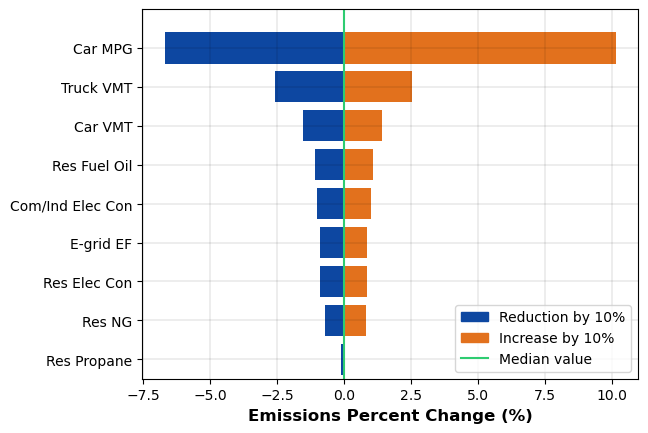

In [78]:
# Draw bars for 5%
for y, value in zip(ys, value_5):
    plt.broken_barh([(base, -np.abs(base-value))], (y - height/2,height), facecolors=[color_5,color_5])

# Draw bars for 95%
for y, value2 in zip(ys, value_95):
    plt.broken_barh([(base, np.abs(base-value2))], (y - height/2, height),facecolors=[color_95,color_95])

# Add vertical line for median value
plt.axvline(base, color=color_line, linewidth=1.5, label='Median value')  

# Modify the graph
plt.ylim([-0.5, 9])
plt.yticks(ys, yTick_label)
plt.grid(linewidth=0.1, color='black')
plt.xlabel('Emissions Percent Change (%)', fontsize=12, fontweight='bold')

# Add legend
handles = [Patch(color=color_5, label='Reduction by 10%'), Patch(color=color_95, label='Increase by 10%'),
           Line2D([0], [0], color=color_line, linewidth=1.5, label='Median value')]
plt.legend(handles=handles, loc='lower right')
plt.show()